# # Analyze Supermarket Data Across the Country - Company XYZ

## Step 1 - Loading the Dataset
In this step, I combined the dataset from each branch (3 branches) into one dataset for easy analysis. I wrote the syntaxes that will read multiple files from my current working directory and exported a CSV file after combining.

#### Importing Libraries

In [2]:
import os
import glob
import pandas as pd
os.chdir("/kaggle/input/datasets/oladipupohilton/supermarket") #Current working directory that contains your dataset and code file

#### Using glob to match the pattern "csv"

In [3]:
extension = 'csv'
all_files = [i for i in glob.glob(f'*.{extension}')]

print(all_files)


['Lagos_Branch.csv', 'Port_Harcourt_Branch.csv', 'Abuja_Branch.csv']


#### Combining all the files in the generated list above and export to a CSV

In [4]:
#combine all files in the list
combined_csv = pd.concat([pd.read_csv(f) for f in all_files])
#print(combined_csv)

In [5]:
#export to csv

combined_csv.to_csv("/kaggle/working/combined.csv", index=False, encoding='utf-8-sig')

#### Reading the CSV file using `pd.read_csv` method

In [6]:
df = pd.read_csv("/kaggle/working/combined.csv")


## Step 2 - Data Exploration
In this step I explored the loaded dataset using some built-in Pandas function. I began to think about my analytical approach from here.

### Importing Libraries

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')  
import warnings
warnings.filterwarnings('ignore')

#### Using the head() method to view first few rows of the dataset

In [8]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Lagos,Member,Female,Health and beauty,26888.4,7,9410.94,197629.74,1/5/2019,13:08,Epay,188218.8,4.761905,9410.94,9.1
1,631-41-3108,A,Lagos,Normal,Male,Home and lifestyle,16678.8,7,5837.58,122589.18,3/3/2019,13:23,Card,116751.6,4.761905,5837.58,7.4
2,123-19-1176,A,Lagos,Member,Male,Health and beauty,20959.2,8,8383.68,176057.28,1/27/2019,20:33,Epay,167673.6,4.761905,8383.68,8.4
3,373-73-7910,A,Lagos,Normal,Male,Sports and travel,31071.6,7,10875.06,228376.26,2/8/2019,10:37,Epay,217501.2,4.761905,10875.06,5.3
4,355-53-5943,A,Lagos,Member,Female,Electronic accessories,24782.4,6,7434.72,156129.12,2/25/2019,14:36,Epay,148694.4,4.761905,7434.72,5.8


#### Checking the number of rows and columns present in the data using the shape attribute.

In [9]:
df.shape

(1000, 17)

#### Generating the names of the columns using the columns attribute.

In [10]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

#### Statiscal Summary
The describe method provides the data statistical summary for the dataset, I used this method to explore the statistical summary.

In [11]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.00000
mean,20041.966800,5.510000,5536.572840,116268.029640,110731.456800,4.761905e+00,5536.572840,6.97270
std,9538.066205,2.923431,4215.177173,88518.720636,84303.543463,6.131498e-14,4215.177173,1.71858
min,3628.800000,1.000000,183.060000,3844.260000,3661.200000,4.761905e+00,183.060000,4.00000
25%,11835.000000,3.000000,2132.955000,44792.055000,42659.100000,4.761905e+00,2132.955000,5.50000
50%,19882.800000,5.000000,4351.680000,91385.280000,87033.600000,4.761905e+00,4351.680000,7.00000
75%,28056.600000,8.000000,8080.290000,169686.090000,161605.800000,4.761905e+00,8080.290000,8.50000
max,35985.600000,10.000000,17874.000000,375354.000000,357480.000000,4.761905e+00,17874.000000,10.00000


## gjh

#### Handling Missing values
The `isnull`, and `notna` methods provide a quick overview of the missing data occurence, I used that to observe the presence of missing data in the dataset. I also added the sum method to get a summary and not boolean values.

In [12]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

#### Data Information
The `info()` function is used to print a concise summary of a DataFrame. This method prints information about a DataFrame including the index dtype and column dtypes, non-null values and memory usage. I used this method to observe the data type of each feature.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

## Step 3 - Dealing with DateTime Features

From the summary above, I observed that the `date` and `time` columns were not in the appropriate data type,
I convert to `datetime` datatype using the `to_datetime()` method. After that was done, I used the `dtype`attribute 
to confirm the datatype. 

#### Used `to_datetime()' to convert the `date` column to `datetime`

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

#### Checking the datatype to confirm if it's in `datetime`

In [15]:
df['Date'].dtype

dtype('<M8[ns]')

#### Repeating the two steps above to the `time` column

In [16]:
df['Time'] = pd.to_datetime(df['Time'])

In [17]:
df['Time'].dtype

dtype('<M8[ns]')

## Extracting Features from date & time

#### Extracting the Day feature from the `Date` column, and save to a new `Day` column

In [18]:
df['Day'] = df['Date'].dt.day

#### Extracting the Month feature from the `Date` column, and saving to a new `Month` column

In [19]:
df['Month'] = df['Date'].dt.month

#### Extracting the Year feature from the `Date` column, and saving to a new `Year` column  

In [20]:
df['Year'] = df['Date'].dt.year

#### Extracting the `Hour` feature from the `Time` column and saving to a new `Hour` column

In [21]:
df['Hour'] = df['Time'].dt.hour

In [22]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,Time,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Year,Hour
0,750-67-8428,A,Lagos,Member,Female,Health and beauty,26888.4,7,9410.94,197629.74,...,2026-05-20 13:08:00,Epay,188218.8,4.761905,9410.94,9.1,5,1,2019,13
1,631-41-3108,A,Lagos,Normal,Male,Home and lifestyle,16678.8,7,5837.58,122589.18,...,2026-05-20 13:23:00,Card,116751.6,4.761905,5837.58,7.4,3,3,2019,13
2,123-19-1176,A,Lagos,Member,Male,Health and beauty,20959.2,8,8383.68,176057.28,...,2026-05-20 20:33:00,Epay,167673.6,4.761905,8383.68,8.4,27,1,2019,20
3,373-73-7910,A,Lagos,Normal,Male,Sports and travel,31071.6,7,10875.06,228376.26,...,2026-05-20 10:37:00,Epay,217501.2,4.761905,10875.06,5.3,8,2,2019,10
4,355-53-5943,A,Lagos,Member,Female,Electronic accessories,24782.4,6,7434.72,156129.12,...,2026-05-20 14:36:00,Epay,148694.4,4.761905,7434.72,5.8,25,2,2019,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,552-44-5977,B,Abuja,Member,Male,Health and beauty,22320.0,8,8928.00,187488.00,...,2026-05-20 19:08:00,Card,178560.0,4.761905,8928.00,6.2,3,1,2019,19
996,430-53-4718,B,Abuja,Member,Male,Health and beauty,27133.2,8,10853.28,227918.88,...,2026-05-20 15:46:00,Card,217065.6,4.761905,10853.28,8.4,28,1,2019,15
997,602-16-6955,B,Abuja,Normal,Female,Sports and travel,27576.0,10,13788.00,289548.00,...,2026-05-20 18:10:00,Epay,275760.0,4.761905,13788.00,6.0,24,1,2019,18
998,690-01-6631,B,Abuja,Normal,Male,Fashion accessories,6296.4,10,3148.20,66112.20,...,2026-05-20 18:35:00,Epay,62964.0,4.761905,3148.20,6.6,22,2,2019,18


#### Pandas provide the `nunique()` method to get a count of unique values, while the `unique()` function is used to get unique values of Series object.

#### From the hours information, I determined the numbers of unique hours of sales in the supermarket, and returned an array of the hours using the unique() method

In [23]:
df['Hour'].nunique()

11

In [24]:
df['Hour'].unique()

array([13, 20, 10, 14, 17, 16, 19, 11, 18, 12, 15], dtype=int32)

In [25]:
#[Write your Code Here]

## Step 4 - Unique Values in Columns

With the line of code below, I got a list of the categorical columns in the dataset. I iterated through the columns and checked if each element is an object datatype. The result is saved to the "categorical_columns" variable
as a list.

In [26]:
categorical_columns = [col for col in df.columns if df[col].dtype == "object" ]
categorical_columns

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Payment']

#### From the information above, I generated the unique values in the categorical columns

In [27]:
#Unique values in Branch Column
df['Branch'].unique().tolist()

['A', 'C', 'B']

In [28]:
print("Total Number of unique values in the Branch Column : {}". format(len(df['Branch'].unique().tolist())))

Total Number of unique values in the Branch Column : 3


In [29]:
#Unique values in Customer type Column
df['Customer type'].unique().tolist()

['Member', 'Normal']

In [30]:
#Getting the Unique values in All Columns
for col in categorical_columns:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print("-" * 50)

Unique values in Invoice ID:
['750-67-8428' '631-41-3108' '123-19-1176' '373-73-7910' '355-53-5943'
 '665-32-9167' '365-64-0515' '252-56-2699' '829-34-3910' '656-95-9349'
 '765-26-6951' '329-62-1586' '636-48-8204' '549-59-1358' '227-03-5010'
 '189-17-4241' '848-62-7243' '595-11-5460' '129-29-8530' '272-65-1806'
 '162-48-8011' '106-35-6779' '635-40-6220' '817-48-8732' '199-75-8169'
 '877-22-3308' '232-11-3025' '382-03-4532' '287-21-9091' '381-20-0914'
 '633-44-8566' '504-35-8843' '873-51-0671' '594-34-4444' '865-92-6136'
 '212-62-1842' '704-48-3927' '630-74-5166' '645-44-1170' '642-32-2990'
 '638-60-7125' '668-90-8900' '870-54-3162' '802-70-5316' '700-81-1757'
 '354-39-5160' '575-30-8091' '239-10-7476' '685-64-1609' '238-49-0436'
 '746-94-0204' '782-95-9291' '275-28-0149' '101-17-6199' '687-47-8271'
 '796-32-9050' '105-31-1824' '249-42-3782' '827-26-2100' '175-54-2529'
 '407-63-8975' '851-28-6367' '586-25-0848' '400-60-7251' '831-07-6050'
 '856-22-8149' '749-24-1565' '888-02-0338' '802-

In [31]:
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Invoice ID: 1000 unique values
Branch: 3 unique values
City: 3 unique values
Customer type: 2 unique values
Gender: 2 unique values
Product line: 6 unique values
Payment: 3 unique values


#### The `value_counts()` function was used to get a Series containing counts of unique values. For the categorical columns above, I generated the count figure of the values using the `value_counts() ` method.


In [32]:
#Example
df['City'].value_counts()

City
Lagos            340
Abuja            332
Port Harcourt    328
Name: count, dtype: int64

In [33]:
#value counts for categorical columns
for col in categorical_columns:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("-" * 50)

Value counts for Invoice ID:
Invoice ID
303-96-2227    1
750-67-8428    1
631-41-3108    1
123-19-1176    1
373-73-7910    1
              ..
636-48-8204    1
329-62-1586    1
765-26-6951    1
656-95-9349    1
829-34-3910    1
Name: count, Length: 1000, dtype: int64
--------------------------------------------------
Value counts for Branch:
Branch
A    340
B    332
C    328
Name: count, dtype: int64
--------------------------------------------------
Value counts for City:
City
Lagos            340
Abuja            332
Port Harcourt    328
Name: count, dtype: int64
--------------------------------------------------
Value counts for Customer type:
Customer type
Member    501
Normal    499
Name: count, dtype: int64
--------------------------------------------------
Value counts for Gender:
Gender
Female    501
Male      499
Name: count, dtype: int64
--------------------------------------------------
Value counts for Product line:
Product line
Fashion accessories       178
Food and beverag

## Step 5 - Aggregration with GroupBy

#### I created a groupby object with the "City Column", and aggregation function of sum and mean to determine the total and average gross income for each City. 

In [34]:
city_group = df.groupby('City')
print(city_group['gross income'].sum())
print(city_group['gross income'].mean())

City
Abuja            1820531.52
Lagos            1820577.78
Port Harcourt    1895463.54
Name: gross income, dtype: float64
City
Abuja            5483.528675
Lagos            5354.640529
Port Harcourt    5778.852256
Name: gross income, dtype: float64


#### Using the groupby object, I displayed a table that shows the gross income of each city, and determined the city with the highest total gross income.

In [35]:
Gross_income_city = df.groupby('City')['gross income'].sum().sort_values(ascending=False)
Gross_income_city

City
Port Harcourt    1895463.54
Lagos            1820577.78
Abuja            1820531.52
Name: gross income, dtype: float64

In [59]:
print("The City with the highest total gross income is :\n {}" .format(Gross_income_city.head(1)))

The City with the highest total gross income is :
 City
Port Harcourt    1895463.54
Name: gross income, dtype: float64


In [37]:
# Average Unit Price by City
print(df.groupby('City')['Unit price'].mean())

# Total Quantity sold by City
print(df.groupby('City')['Quantity'].sum())

City
Abuja            20037.339759
Lagos            19721.107059
Port Harcourt    20379.248780
Name: Unit price, dtype: float64
City
Abuja            1820
Lagos            1859
Port Harcourt    1831
Name: Quantity, dtype: int64


## Step 6 - Data Visualization

In this section, I answered some questions by generating charts and using different plotting styles. I used the `Seaborn visualization` library to generate plots. For all visualizations, I included a chart title by using the seaborn `set_title` method

#### Using `countplot`, I determined the branch with the highest sales record.

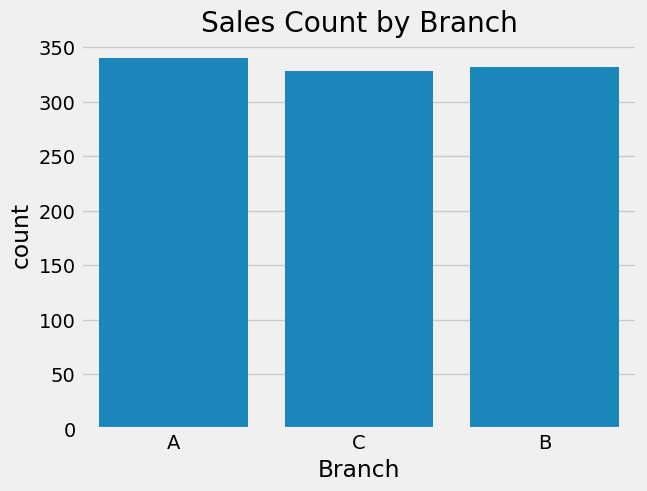

In [38]:
sns.countplot(x='Branch', data=df)
plt.title('Sales Count by Branch')
plt.show()

#### Also explored a countplot for the `Payment` and `City` Column

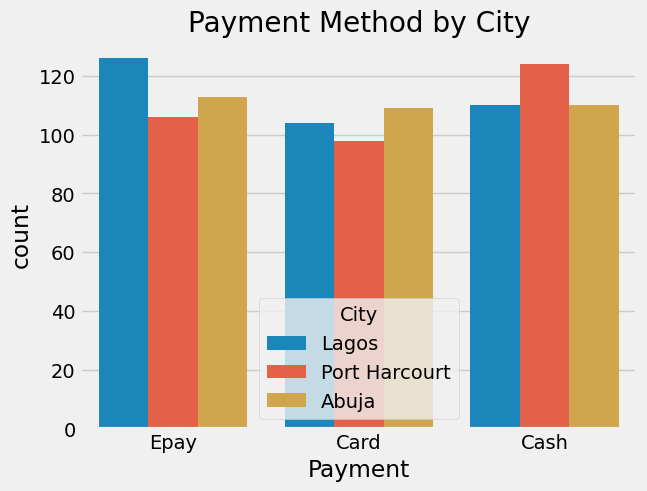

In [39]:
sns.countplot(x='Payment', hue='City', legend= 'brief', data=df)
plt.title('Payment Method by City')
plt.show()

#### Determining the highest & lowest sold product line, using Countplot 
Count Plot Tips- Set the `Product line` column to y-axis to prevent congestion on the x-axis

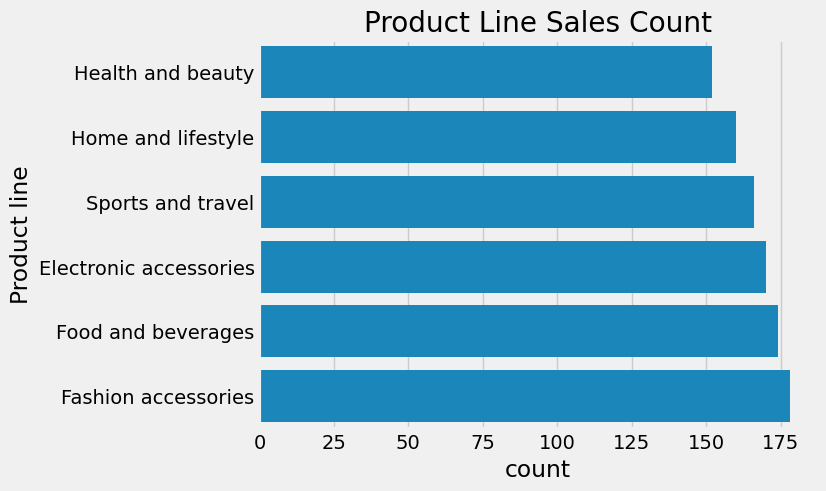

In [40]:
sns.countplot(y='Product line', data=df)
plt.title('Product Line Sales Count')
plt.show()

#### Determining the Payment channel used by most customers to pay for each product line. I set the "product line" column to the y-axis to prevent congestion on the x-axis, and used the "hue" parameter for the "Payment" column. 

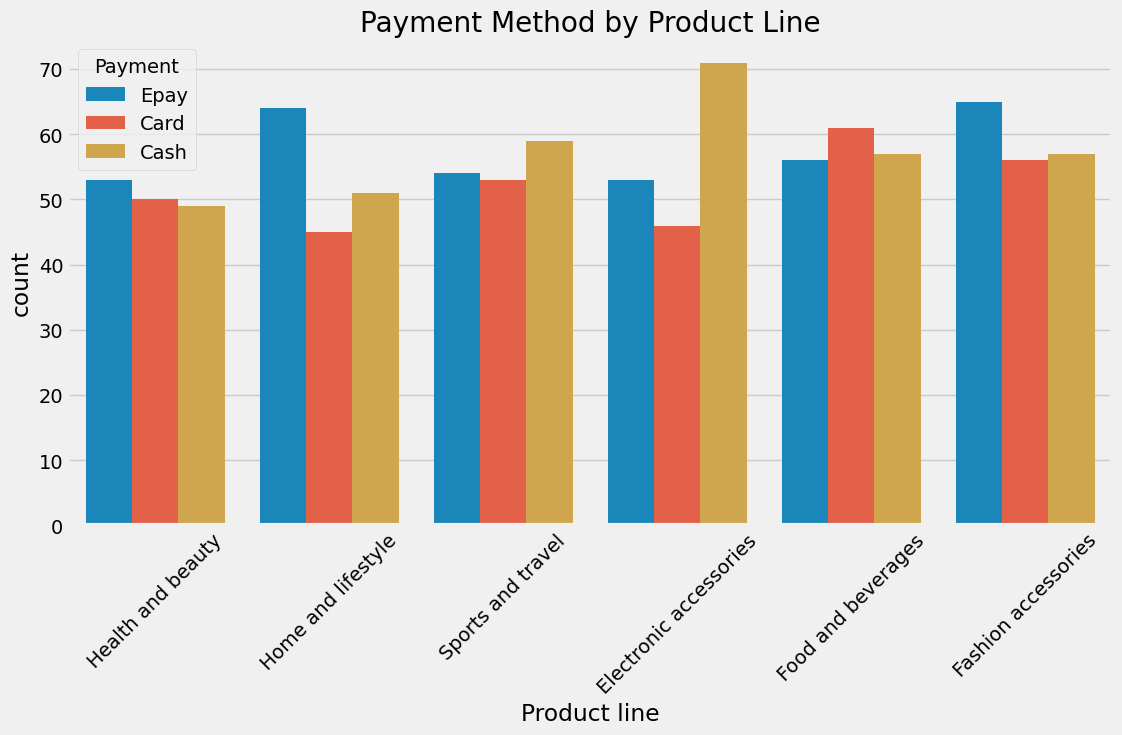

In [41]:
plt.figure(figsize=(12,6))
sns.countplot(x='Product line', hue='Payment', data=df)
plt.xticks(rotation=45)
plt.title('Payment Method by Product Line')
plt.show()

#### Determining the Payment channel for each branch.
I Used the hue parameter for the "branch" column

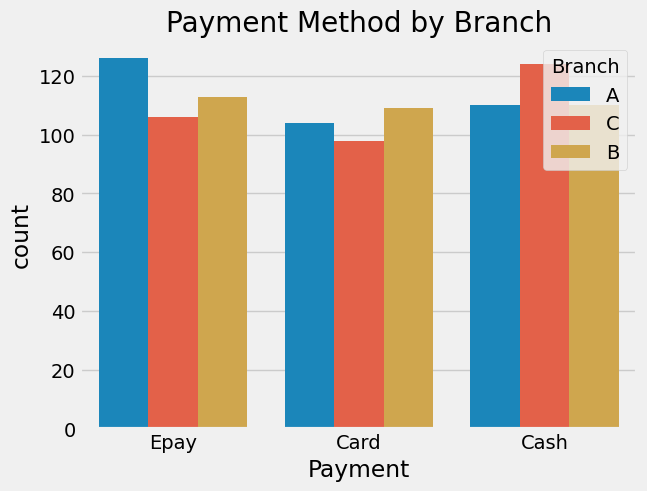

In [42]:
sns.countplot(x='Payment', hue='Branch', data=df)
plt.title('Payment Method by Branch')
plt.show()

#### Determining the branch with the lowest rating. I determined this using a box plot, which gives a statistical summary of the plotted features, and I used this to pick out the branch with the lowest rating from the plot

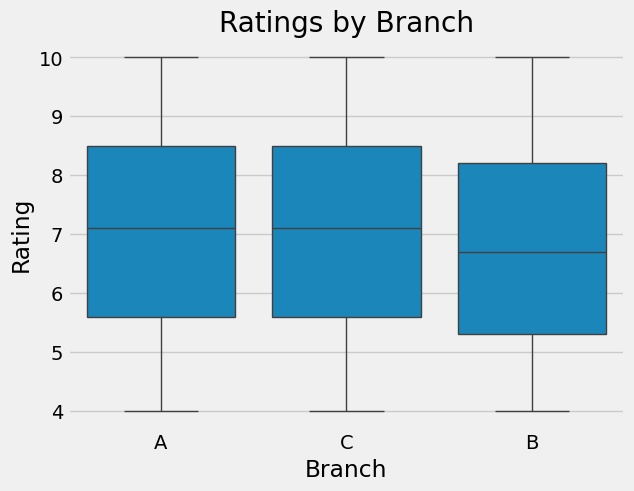

In [43]:
sns.boxplot(x='Branch', y='Rating', data=df)
plt.title('Ratings by Branch')
plt.show()

In [44]:
#Branch B has the lowest rating with more than 75% of ratings less than others

#### The gender type often affects the kind of products being purchased at the supermarket. 
I used a catplot() to generate a visualization for the "product line" on the x-axis, quantity on the y-axis, and hue as gender. 
<br/>


* Plot the same chart, but `Total Column` as the y-axis

* Write a summary of the insights you can pick from this chart.

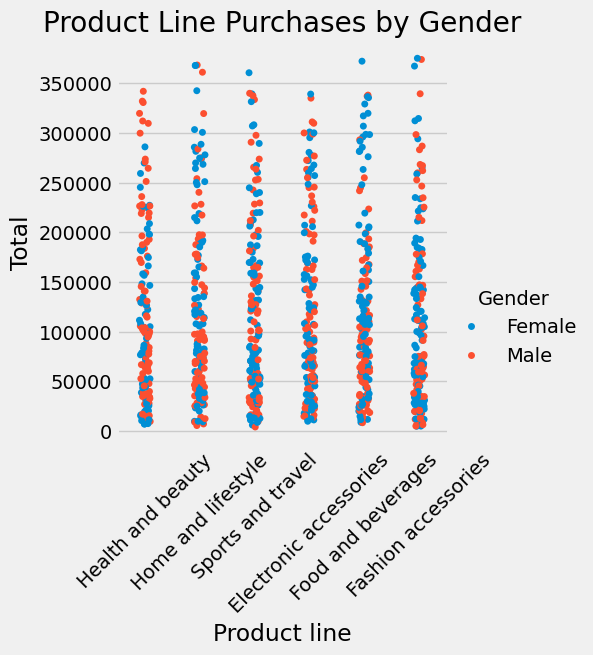

In [80]:
#plt.figure(figsize=(12,6))
sns.catplot(x='Product line', y='Total', hue='Gender', data=df)
plt.xticks(rotation=45)
plt.title('Product Line Purchases by Gender')
plt.show()

#### Exploring the interaction of Unit price on the Quantity of goods purchased.  
* Use the `catplot()` to plot `Product line per unit price`, and `Product line per Quantity`. Set the kind parameter to `point` 
* In a new cell, Write a summary of the insights you uncovered

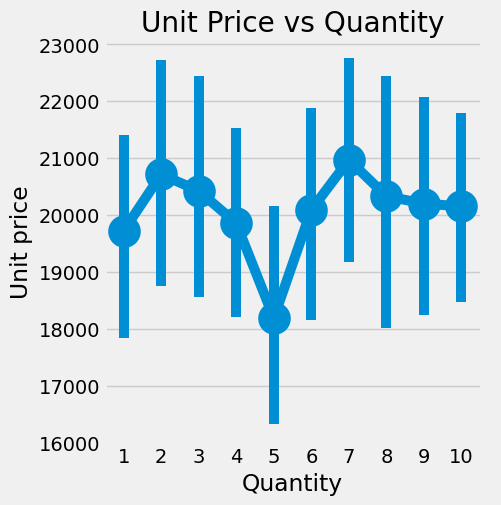

In [78]:
sns.catplot(y='Unit price', x='Quantity',kind= 'point' , data=df)
plt.title('Unit Price vs Quantity')
plt.show()

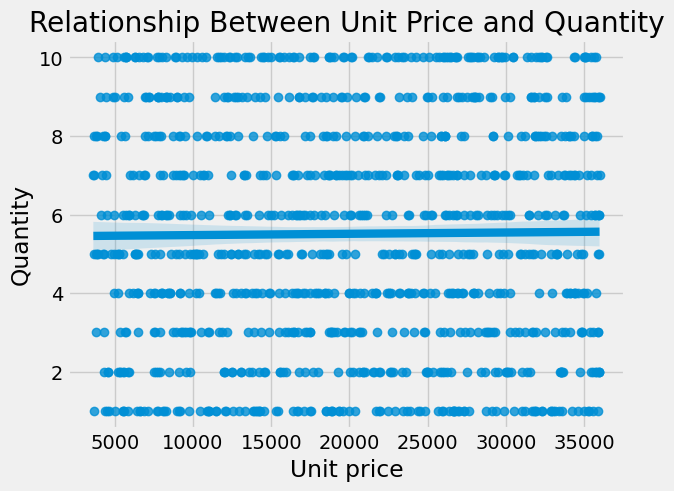

In [77]:
sns.regplot(x='Unit price', y='Quantity', data=df)
plt.title('Relationship Between Unit Price and Quantity')
plt.show()

## Step 7 - StandOut Section
To make your submission standout, 
* You can continue to explore more insights that can be uncovered with different plotting methods.
* Write a detailed summary on your approach, methods and insights. 
* Visit the [link](https://seaborn.pydata.org/tutorial/categorical.html) for more Seaborn visualization plots.


## Step 8 - Documentation.

* Write a detailed `ReadMe` that describes the project, explains important approach you followed to solve the tasks. Find a template in the starter file that can get you started quickly. Note: Do limit yourself to the template, you can include any interesting step that is worth sharing. 
* Write an Executive summary that you can present to `Company XYZ` management. The summary will explain your processes and insights you uncovered that can help the company 